In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [88]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [89]:
df_w = df[df["main_position"].isin(["LW", "RW", "LWF", "RWF"])].copy()
df_clustering = df_w[df_w["low_minutes_flag"] == False].copy()

Selección de métricas

In [90]:
features_clustering = [
    
    # regate / desequilibrio
    "dribble_efficiency",
    
    # creación
    "xg_assist_avg",

    
    # gol
    "goals_avg",
    
    # progresión
    "real_progression",

    # duelos y defensa
    "duels_won_avg",
    "successful_defensive_actions_avg"

]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [92]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   dribble_efficiency  xg_assist_avg  goals_avg  real_progression  \
0            1.657092      -0.207379   1.278335          1.708929   
1            1.666196      -0.619499  -0.638414          0.782708   
2            0.783522      -0.791571  -0.338186         -0.206134   
3            1.499366      -1.198007  -0.870225         -0.342812   
4           -0.033389      -0.114178  -0.262181         -0.879401   

   duels_won_avg  successful_defensive_actions_avg  
0       1.645330                          0.487402  
1       1.958107                          0.299219  
2       1.150492                         -0.039824  
3       1.459991                          0.583645  
4       0.877842                          0.352254  


PCA: Reducción de dimensionalidad

In [93]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.33913933 0.26593841 0.14982233]


In [94]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0  2.387953 -1.270818  1.440112
1  1.564645 -2.174567 -0.152803
2  0.315104 -1.243107  0.036933
3  0.350697 -2.259359 -0.217485
4 -0.412377 -0.936717  0.149253


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

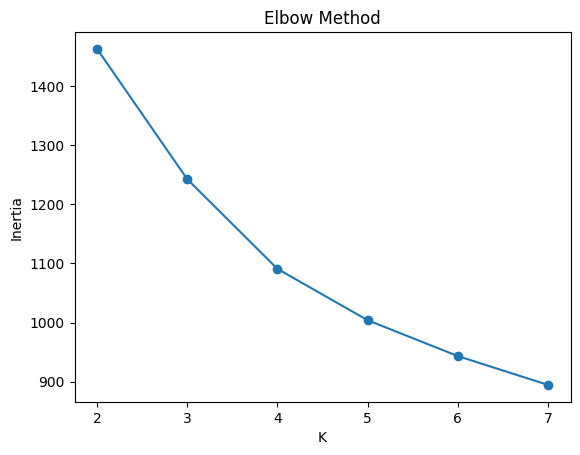

In [95]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [96]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [97]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            dribble_efficiency  xg_assist_avg  goals_avg  real_progression  \
cb_cluster                                                                   
0                     3.948420       0.168790   0.136652          8.384433   
1                     1.465294       0.097426   0.160088          5.242097   
2                     2.187082       0.113605   0.150155          6.107941   
3                     2.360879       0.207474   0.314984          7.861417   

            duels_won_avg  successful_defensive_actions_avg  
cb_cluster                                                   
0                9.800341                          4.500594  
1                6.625682                          4.651232  
2                9.567575                          6.641001  
3                7.254247                          4.059440  


In [98]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
815,Nico Williams,70000000.0,1947,0
1623,J. Doku,65000000.0,1969,0
2255,J. Grealish,60000000.0,1417,0
3564,A. Gordon,60000000.0,2220,0
766,Savinho,50000000.0,1707,0
2446,K. Coman,50000000.0,887,0
3704,T. Kubo,50000000.0,2257,0
3881,M. Kudus,50000000.0,3130,0
1078,J. Gittens,28000000.0,2249,0
3429,C. Führich,28000000.0,2032,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
3841,K. Mitoma,45000000.0,2536,1
3240,Brahim Diaz,40000000.0,1659,1
3476,J. Ramsey,35000000.0,1331,1
1601,S. Adingra,30000000.0,1348,1
2376,J. McGinn,30000000.0,2831,1
2554,V. Tsygankov,30000000.0,2045,1
3028,Pepê,30000000.0,2091,1
2490,Iñaki Williams,25000000.0,2520,1
1673,K. Schade,22000000.0,3066,1
3902,Y. Musah,22000000.0,1449,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
3411,C. Gallagher,50000000.0,1589,2
3383,N. González,35000000.0,2319,2
2548,A. Golovin,30000000.0,1061,2
3656,Samuel Lino,30000000.0,1057,2
1119,O. Bobb,25000000.0,559,2
1648,D. Ndoye,22000000.0,2545,2
1730,J. Lindstrøm,22000000.0,1256,2
2500,M. Zaccagni,20000000.0,3063,2
3207,M. Tavernier,20000000.0,2298,2
3850,C. Summerville,20000000.0,1205,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3184,Rafael Leão,90000000.0,2263,3
3545,K. Kvaratskhelia,80000000.0,1884,3
1588,Gabriel Martinelli,70000000.0,2010,3
2001,Mohamed Salah,55000000.0,3850,3
3300,C. Gakpo,55000000.0,2660,3
3666,Pedro Neto,55000000.0,2885,3
1005,B. Barcola,50000000.0,2166,3
3259,Raphinha,50000000.0,2275,3
1938,Son Heung-Min,45000000.0,1595,3
3895,Álex Baena,40000000.0,2399,3


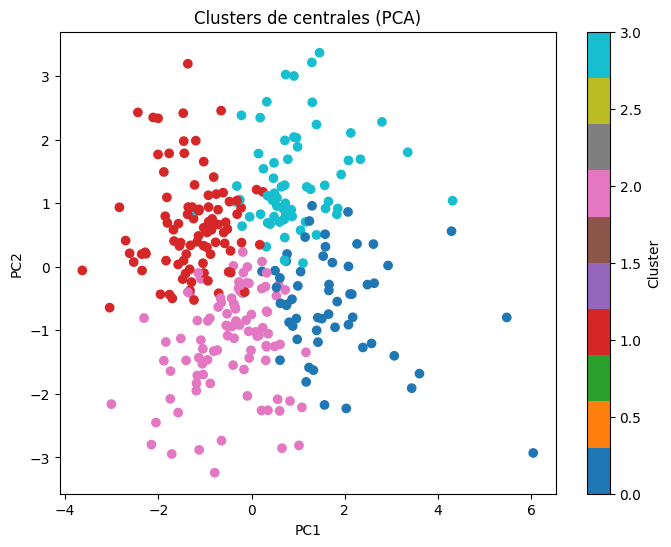

In [99]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

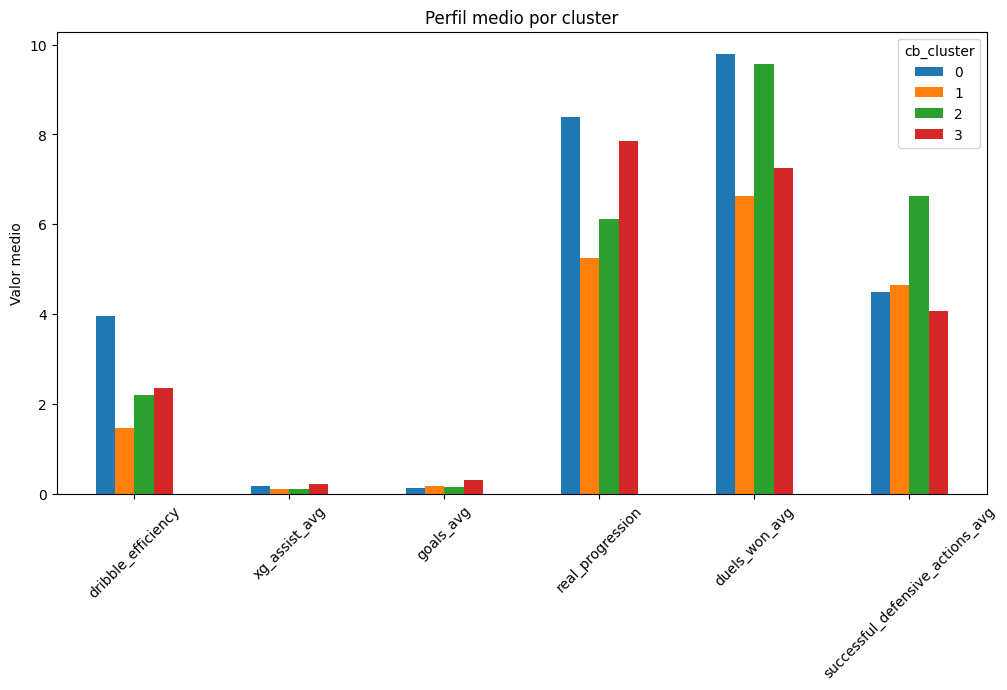

In [100]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

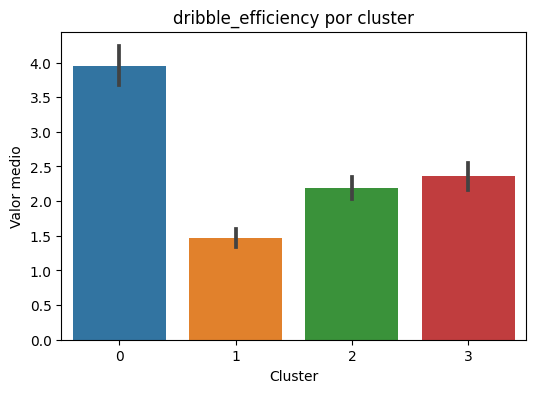

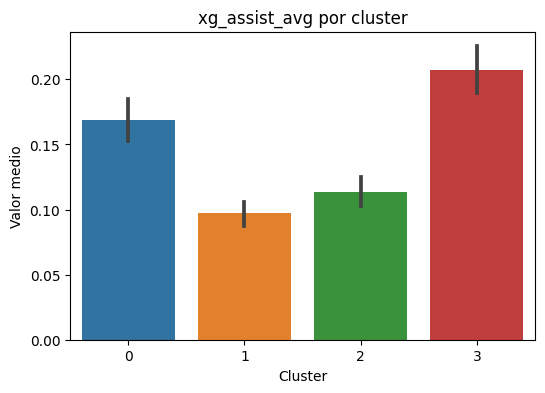

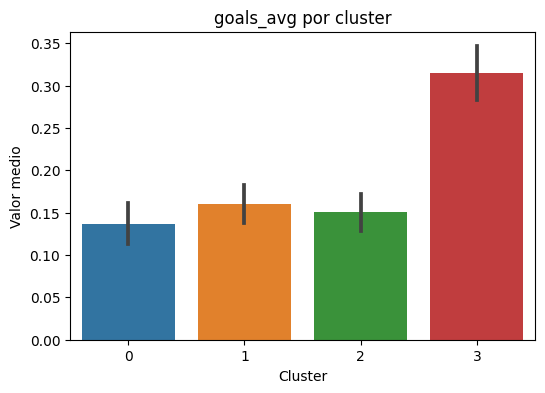

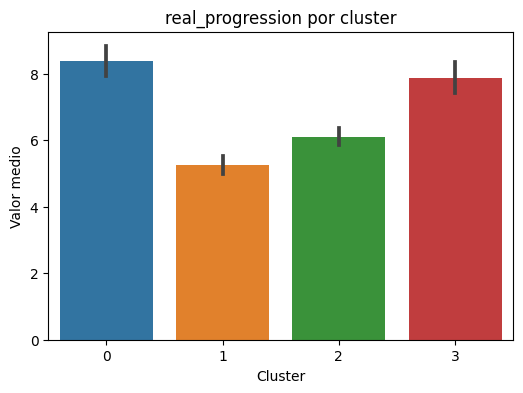

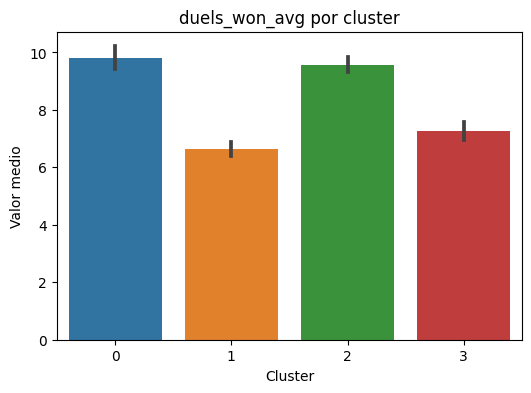

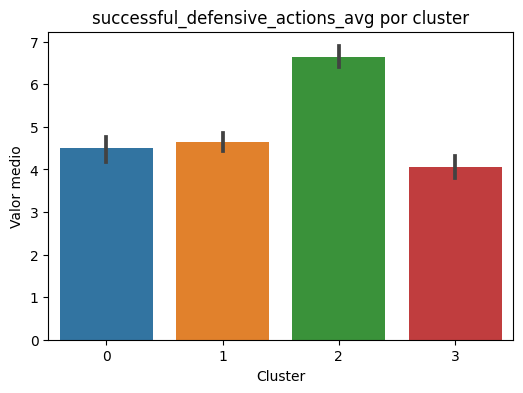

In [101]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

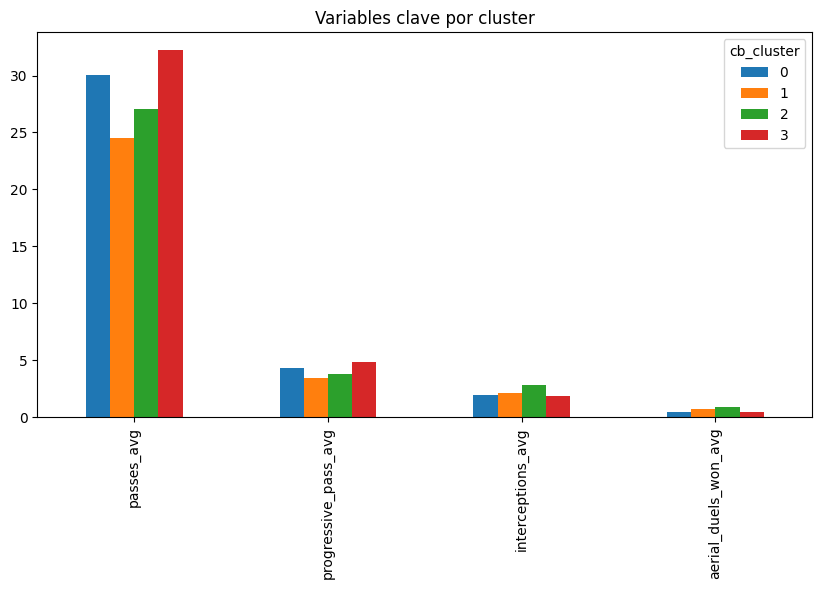

In [102]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

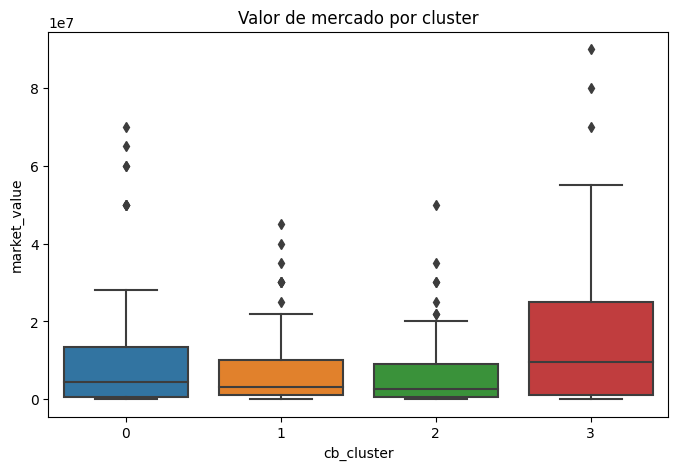

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

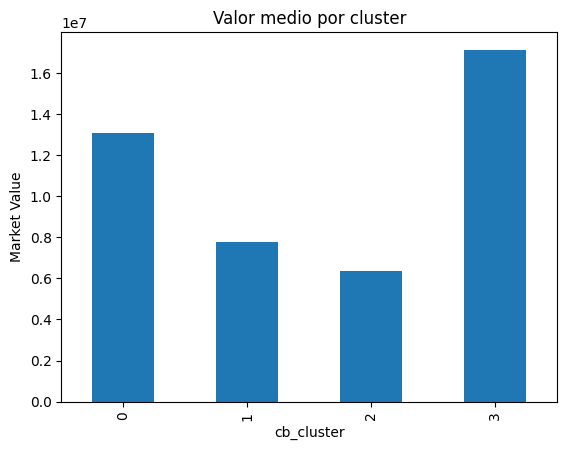

In [104]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [105]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,dribble_efficiency,xg_assist_avg,goals_avg,real_progression,duels_won_avg,successful_defensive_actions_avg
PC1,0.589658,0.426097,0.148747,0.547689,0.298901,-0.243543
PC2,-0.224898,0.261218,0.338443,0.051131,-0.658849,-0.574409
PC3,-0.065997,-0.147176,0.926363,-0.097136,0.238393,0.222640


cluster_labels = {
    0: "Dribbler / ball-progressor winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}


In [106]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back (goal threat)",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target forward",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Goal-scoring forward"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

def assign_role(row):
  
    return w_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [107]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/w_clusters.csv", index=False)